# Pingviinide analüütika

## Seadistused

In [ ]:
!pip install pandas
!pip install duckdb
!pip install matplotlib
!pip install seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 13.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 15.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 15.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 23.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----------------------------- ---------- 5.2/7.2 MB 25.6 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 23.6 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 

In [11]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 7.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 10.9 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 12.6 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- 

In [1]:
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Andmete laadimine

In [2]:
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Andmete kokkuvõte

In [ ]:
duckdb.sql("""
    SUMMARIZE penguins
""").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,species,VARCHAR,Adelie,Gentoo,3,NaN,NaN,NaN,NaN,NaN,344,0.00
1,island,VARCHAR,Biscoe,Torgersen,3,NaN,NaN,NaN,NaN,NaN,344,0.00
2,bill_length_mm,DOUBLE,32.1,59.6,186,43.92192982456142,5.459583713926537,39.262499999999996,44.382,48.51875,344,0.58
3,bill_depth_mm,DOUBLE,13.1,21.5,80,17.151169590643278,1.974793156816781,15.565625,17.318,18.671875,344,0.58
4,flipper_length_mm,DOUBLE,172.0,231.0,51,200.91520467836258,14.061713679356952,190.0,197.06,213.46875,344,0.58
5,body_mass_g,DOUBLE,2700.0,6300.0,77,4201.754385964912,801.9545356980948,3552.34375,4030.5,4769.53125,344,0.58
6,sex,VARCHAR,Female,Male,2,NaN,NaN,NaN,NaN,NaN,344,3.20


## Ilma väärtusteta ridade kustutamine

In [4]:
penguins_not_null = penguins.dropna()
penguins_not_null

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Grupeerimine liikide kaupa

In [5]:
duckdb.sql("""
    select species, count(*) as count
    from penguins_not_null
    group by species
    order by species
""").df()

,species,count
0,Adelie,146
1,Chinstrap,68
2,Gentoo,119


## Liikide grupeerimine saarte kaupa koos kogusega

In [6]:
duckdb.sql("""
    select species, island, count(*) as count
    from penguins_not_null
    group by island, species
    order by island, species
""").df()

,species,island,count
0,Adelie,Biscoe,44
1,Gentoo,Biscoe,119
2,Adelie,Dream,55
3,Chinstrap,Dream,68
4,Adelie,Torgersen,47


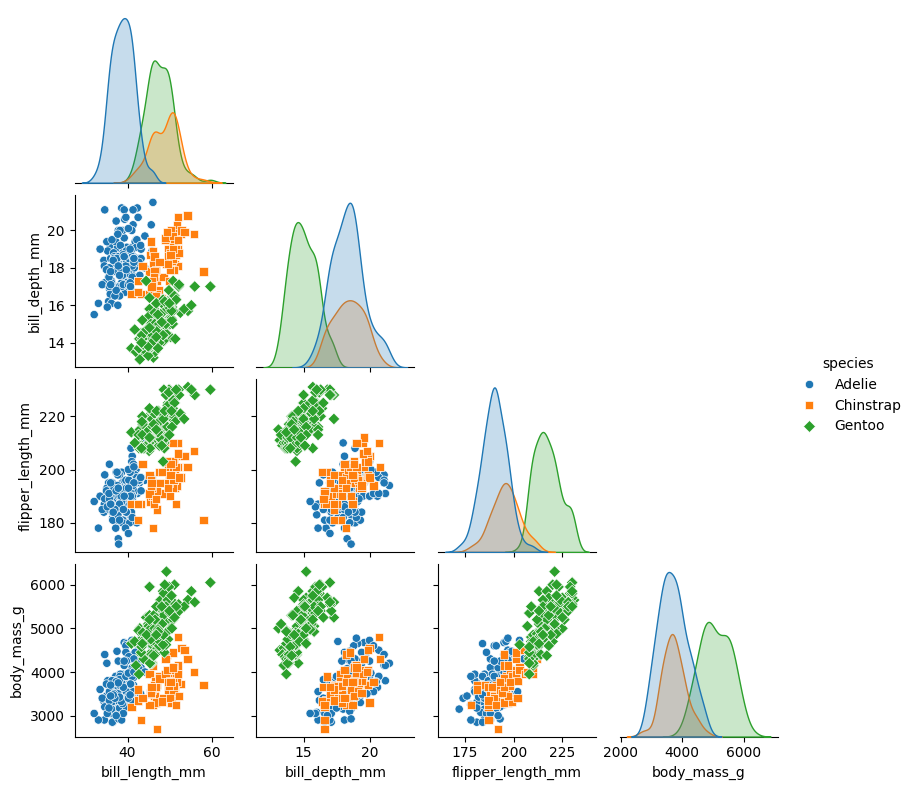

In [7]:
sns.pairplot(penguins_not_null, hue = "species", markers=["o", "s", "D"], height = 2, corner=True); # semikoolon võtab maha tabeli kirjelduse

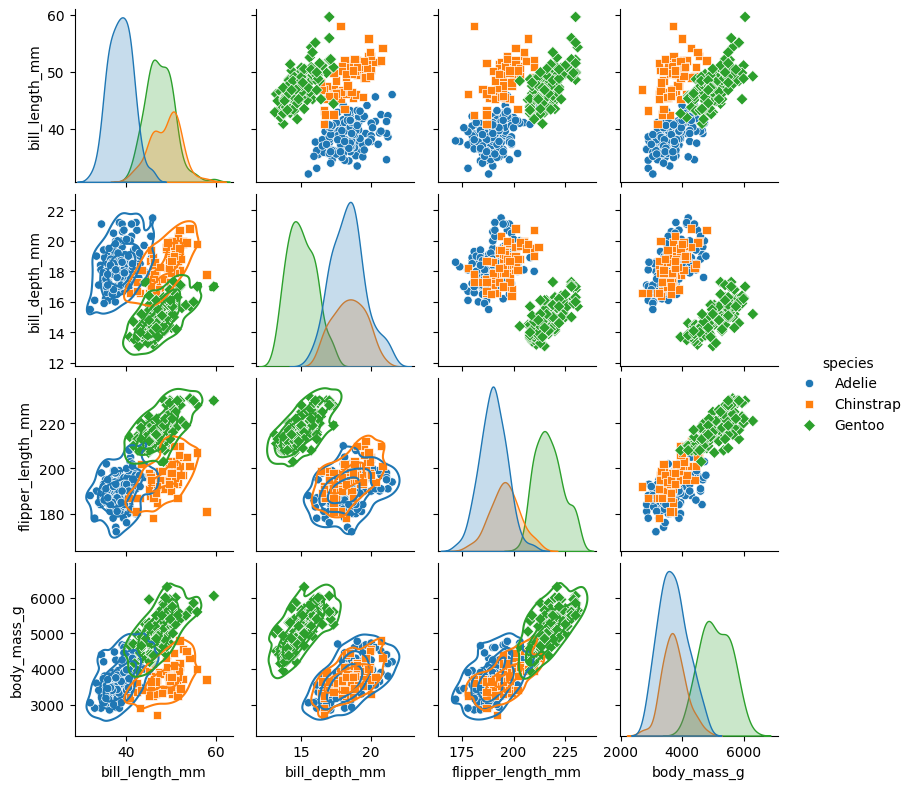

In [8]:
g = sns.pairplot(penguins_not_null, hue = "species", markers=["o", "s", "D"], height = 2)
g.map_lower(sns.kdeplot, levels=4);

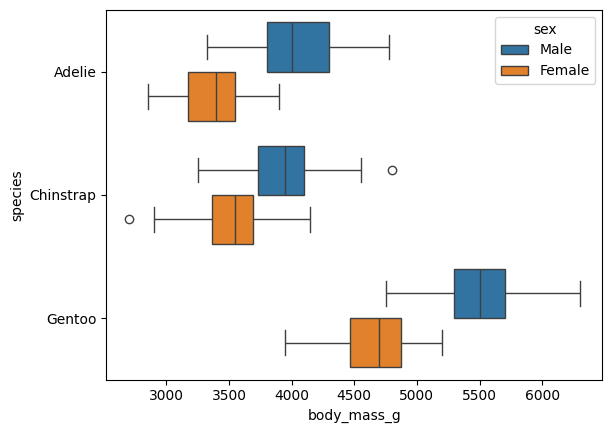

In [9]:
sns.boxplot(penguins_not_null, x="body_mass_g", y="species", hue="sex");

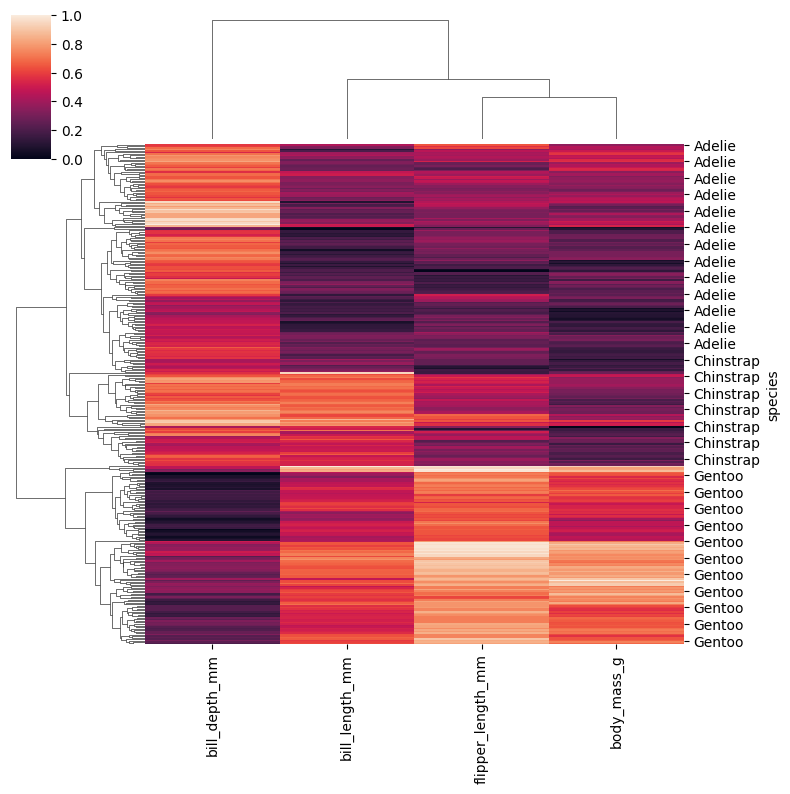

In [10]:
sns.clustermap(
    penguins_not_null[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]].set_index("species"),
    standard_scale=1,
    figsize=(8,8) # tabeli suuruse muutmiseks
);

## Ennustamine

In [12]:
import statsmodels.formula.api as smf

penguins_not_null["sex_binary"] = (penguins_not_null["sex"] == "Male").astype(int)

model = smf.logit("sex_binary ~ body_mass_g + flipper_length_mm", data=penguins_not_null).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.558531
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             sex_binary   No. Observations:                  333
Model:                          Logit   Df Residuals:                      330
Method:                           MLE   Df Model:                            2
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.1942
Time:                        14:44:16   Log-Likelihood:                -185.99
converged:                       True   LL-Null:                       -230.80
Covariance Type:            nonrobust   LLR p-value:                 3.449e-20
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.0868      2.662      2.662      0.008       1.869      12.305
body_mas

In [13]:
new_data = pd.DataFrame({
    "body_mass_g": [4000, 3500, 5000],
    "flipper_length_mm": [200, 185, 210]
})
new_data["pred_prob"] = model.predict(new_data)
new_data["pred_class"] = (new_data["pred_prob"] > 0.5).astype(int)
new_data

,body_mass_g,flipper_length_mm,pred_prob,pred_class
0,4000,200,0.392569,0
1,3500,185,0.394442,0
2,5000,210,0.804225,1
